### Installation des dépendances

Exécutez la commande suivante pour installer les dépendances à partir de la racine du repo:

```bash
uv sync --package qnn-mnist
```

Un environnement virtuel devrait être créé, il pourra être utilisé avec ce notebook.

In [1]:
import torch
from torchvision import datasets
from torchvision.transforms import v2 as transforms



## Manipulation du jeu de données

In [2]:
# Charger MNIST
transform = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
])

mnist_train = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

mnist_test = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

Training dataset size: 60000
Test dataset size: 10000


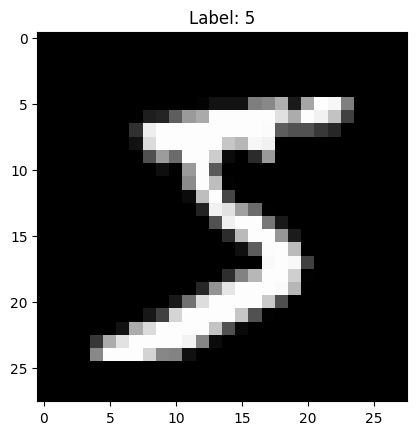

In [3]:
# Show training and test datasets sizes

print(f"Training dataset size: {len(mnist_train)}")
print(f"Test dataset size: {len(mnist_test)}")

# Show an example of an image and its label
import matplotlib.pyplot as plt
image, label = mnist_train[0]
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Label: {label}")
plt.show()

In [4]:
# Filter the dataset to only include digits 0 and 1
def filter_digits(dataset, allowed_digits=(0, 1)):
    images = []
    labels = []

    for image, label in dataset:
        if label in allowed_digits:
            images.append(image)
            labels.append(label)

    images = torch.stack(images)
    labels = torch.tensor(labels, dtype=torch.long)

    return images, labels

x_train, y_train = filter_digits(mnist_train)
x_test, y_test = filter_digits(mnist_test)

print(f"Filtered training dataset size (0 and 1): {len(x_train)}")
print(f"Filtered test dataset size (0 and 1): {len(x_test)}")

Filtered training dataset size (0 and 1): 12665
Filtered test dataset size (0 and 1): 2115


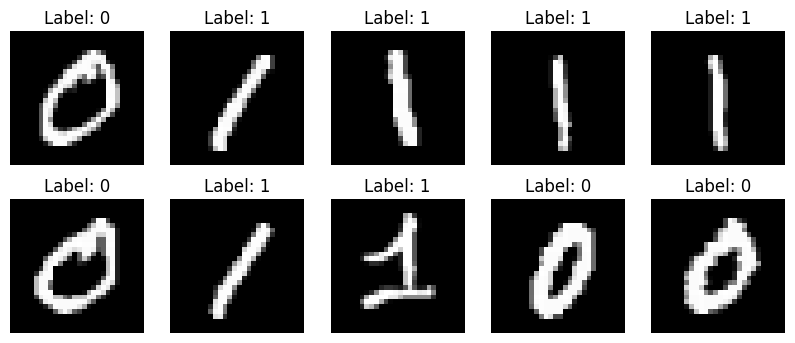

In [5]:
# Show a composed plot of 10 images of digits 0 and 1

def show_sample_images(images, labels, num_images=10):
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    for i in range(10):
        img, lbl = x_train[i], y_train[i]
        ax = axes[i // 5, i % 5]
        ax.imshow(img.squeeze(), cmap='gray')
        ax.set_title(f"Label: {lbl}")
        ax.axis('off')
    plt.show()

show_sample_images(x_train, y_train)

In [6]:
# Show the shape of the image tensor
print(f"Image shape: {image.shape}")

Image shape: torch.Size([1, 28, 28])


## Extraire des caractéristique de MNIST avec PCA

In [7]:
import numpy as np

# Retire la dimension du canal et aplatit chaque image.
# Forme initiale : [N, 1, 28, 28]
# Forme finale : [N, 784]
x_train_flat = x_train.reshape(len(x_train), -1).numpy()
x_test_flat = x_test.reshape(len(x_test), -1).numpy()

x_train_flat.shape, x_test_flat.shape

((12665, 784), (2115, 784))

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

print(f"Values before scaling: mean={x_train_flat.mean():.4f}, std={x_train_flat.std():.4f}")

x_train_scaled = scaler.fit_transform(x_train_flat)
x_test_scaled = scaler.transform(x_test_flat)

print(f"Values after scaling: mean={x_train_scaled.mean():.4f}, std={x_train_scaled.std():.4f}")


Values before scaling: mean=0.1215, std=0.3011
Values after scaling: mean=-0.0000, std=0.8871


In [9]:
from sklearn.decomposition import PCA
n_features = 4

pca = PCA(n_components=n_features)

x_train_reduced = pca.fit_transform(x_train_scaled)
x_test_reduced = pca.transform(x_test_scaled)

print(f"Shape after PCA: {x_train_reduced.shape}, {x_test_reduced.shape}")

Shape after PCA: (12665, 4), (2115, 4)


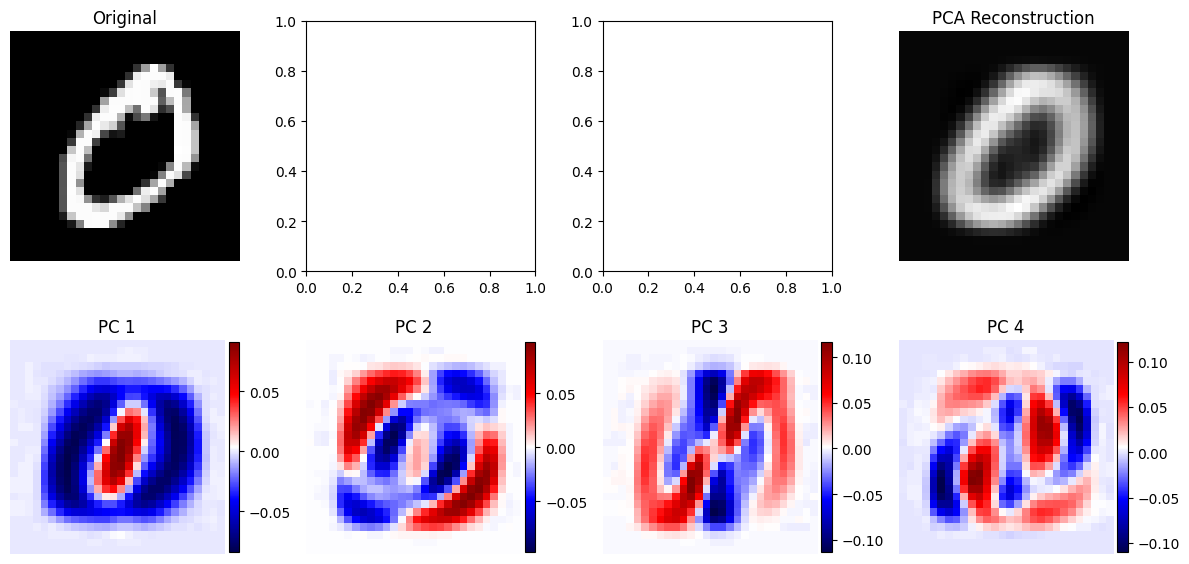

In [10]:
def visualize_preprocessing_and_pca(n_features=8, idx=0):
    """
    Visualize preprocessing steps and PCA features for one example image.
    
    Parameters:
    - idx: index of the image to visualize (default: 0)
    - n_features: number of PCA components to display (default: 8)
    """
    # Original tensor image (28x28)
    orig = x_train[idx].squeeze().numpy()
    # Flattened view reshaped back
    flat = x_train_flat[idx].reshape(28, 28)
    # Inverse transform a scaled sample for visualization
    scaled_unscaled = scaler.inverse_transform(x_train_scaled[idx].reshape(1, -1)).reshape(28, 28)
    # PCA reconstruction (inverse transform -> then inverse scale -> reshape)
    pca_recon_scaled = pca.inverse_transform(x_train_reduced[idx:idx+1])
    pca_recon = scaler.inverse_transform(pca_recon_scaled).reshape(28, 28)
    
    # Principal components as images
    components = pca.components_.reshape(pca.n_components_, 28, 28)
    
    # Create figure with 4 + n_features subplots
    num_cols = min(4, n_features + 4)
    num_rows = (n_features + 4 + num_cols - 1) // num_cols
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 3 * num_rows))
    axes = axes.flatten() if num_rows * num_cols > 1 else [axes]
    
    # Plot preprocessing steps
    axes[0].imshow(orig, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
    axes[3].imshow(pca_recon, cmap='gray'); axes[3].set_title('PCA Reconstruction'); axes[3].axis('off')
    
    # Plot all n_features principal components
    for i in range(n_features):
        ax = axes[4 + i]
        im = ax.imshow(components[i], cmap='seismic')
        ax.set_title(f'PC {i+1}')
        ax.axis('off')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    
    # Hide unused subplots
    for i in range(4 + n_features, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Call the function
visualize_preprocessing_and_pca(n_features, idx=0)

## Extraction de caractéristiques avec une couche de convolution simple

In [15]:
import torch.nn as nn

class SimpleConvPreprocessor(nn.Module):
    def __init__(self, n_features=4):
        super().__init__()

        self.features = nn.Sequential(
            # Entrée : [N, 1, 28, 28]
            # Sortie : [N, n_features, 26, 26]
            # Pourquoi 26 ? Un noyau 3x3 sans padding réduit 28 à 26.
            nn.Conv2d(in_channels=1, out_channels=n_features, kernel_size=3),
            nn.ReLU(),

            # Réduit la résolution spatiale.
            # Sortie : [N, n_features, 13, 13]
            nn.MaxPool2d(kernel_size=2),

            # Transforme les cartes de caractéristiques en vecteurs.
            nn.Flatten(),

            # Projette le grand vecteur convolutionnel vers quelques caractéristiques.
            nn.Linear(n_features * 13 * 13, n_features),
        )

    def forward(self, x):
        return self.features(x)

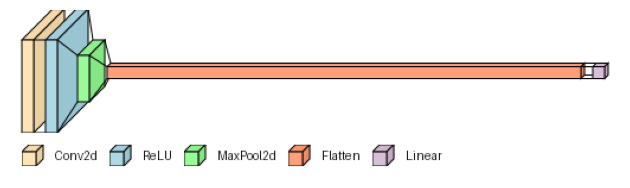

In [16]:
import matplotlib.pyplot as plt
import visualtorch
from torch import nn

n_features = 8

conv_preprocessor = SimpleConvPreprocessor(n_features)

img = visualtorch.layered_view(conv_preprocessor, input_shape=(1, 1, 28, 28), legend=True, scale_xy=3, scale_z=0.3)

plt.axis("off")
plt.tight_layout()
plt.imshow(img)
plt.show()

In [17]:
with torch.no_grad():
    x_train_features = conv_preprocessor(x_train)
    x_test_features = conv_preprocessor(x_test)

x_train_reduced = x_train_features.numpy()
x_test_reduced = x_test_features.numpy()

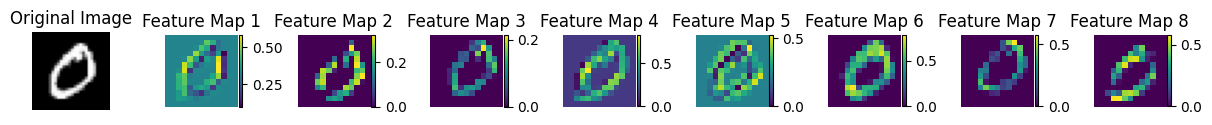

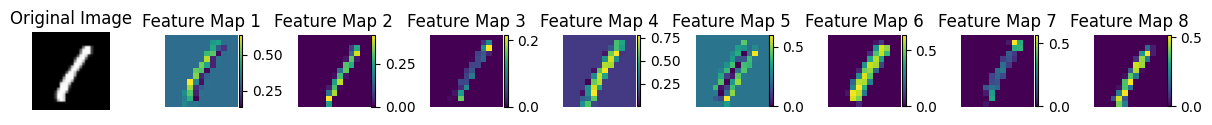

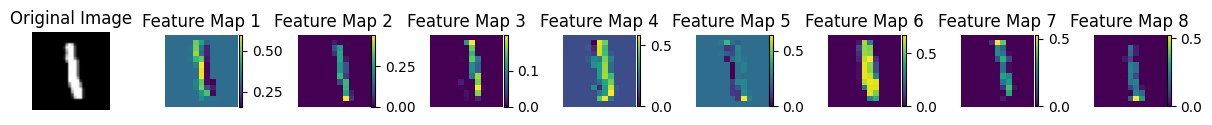

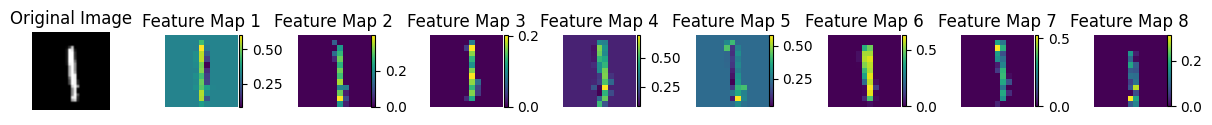

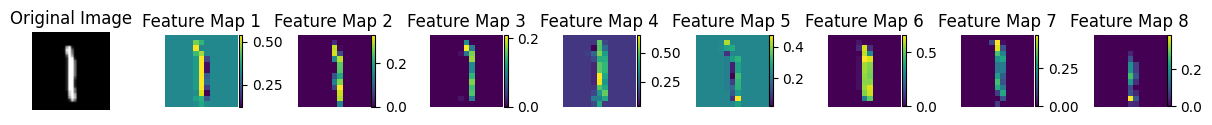

In [18]:
def visualize_preprocessing_and_convolution(n_features=8, idx=0):
    orig = x_train[idx].squeeze().cpu().numpy()

    with torch.no_grad():
        # Keep the convolutional feature maps before Flatten/Linear
        conv_output = conv_preprocessor.features[:3](x_train[idx:idx+1])

    feature_maps = conv_output.squeeze(0).cpu().numpy()  # [4, 13, 13]
    num_maps = min(feature_maps.shape[0], 8)

    fig, axes = plt.subplots(1, 1 + num_maps, figsize=(12, 3))

    axes[0].imshow(orig, cmap="gray")
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    for i in range(num_maps):
        im = axes[1 + i].imshow(feature_maps[i], cmap="viridis")
        axes[1 + i].set_title(f"Feature Map {i+1}")
        axes[1 + i].axis("off")
        fig.colorbar(im, ax=axes[1 + i], fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()
for i in range(5):
    visualize_preprocessing_and_convolution(n_features, idx=i)
